# 01 — Exploration et préparation des données

Ce notebook permet d'explorer le jeu de données automobile, de vérifier sa qualité et de préparer les données pour l'entraînement des modèles de régression.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/raw/vehicles.csv",
    encoding="latin-1"
)

df.head()

,FINANCING_MONTHS,FINANCING_CASHDOWN,FINANCING_MONTHLYPAYMENT,FINANCING_INTEREST,FINANCING_FINANCINGCOST,FINANCING_TOTALOBLIGATION,LEASING_MONTHS,LEASING_CASHDOWN,LEASING_MONTHLYPAYMENT,LEASING_RESIDUALVALUE,...,CERTIFICATION,CERTIFIED,"TRIM,en",OEMID,Video,basePrice,BasePricePlusFee,MSRPPricePlusFee,DeliveryStatus,AS_IS
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,S Mags A/c Caméra,NaN,NaN,18995,18995,20995.0,delivered,0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,SE AWD Alloy Wheels Bluetooth Camera Heated Seats,NaN,NaN,18995,18995,21495.0,delivered,0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,Cube 16 Pieds loading ramp,NaN,NaN,26995,26995,27995.0,delivered,0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,Preferred,NaN,NaN,17995,17995,20995.0,delivered,0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,Highline Mags Sunroof Leather Bluetooth,NaN,NaN,17495,17495,19995.0,delivered,0


In [32]:
df.shape

(543, 106)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543 entries, 0 to 542
Columns: 106 entries, FINANCING_MONTHS to AS_IS
dtypes: bool(1), float64(40), int64(16), object(49)
memory usage: 446.1+ KB


## Sélection des variables

Le jeu de données contient 106 variables. Comme l'objectif du projet est de prédire le prix d'un véhicule, seules les variables pertinentes pour cette prédiction seront conservées avant le nettoyage des données.

In [34]:
df.columns.tolist()

['FINANCING_MONTHS',
 'FINANCING_CASHDOWN',
 'FINANCING_MONTHLYPAYMENT',
 'FINANCING_INTEREST',
 'FINANCING_FINANCINGCOST',
 'FINANCING_TOTALOBLIGATION',
 'LEASING_MONTHS',
 'LEASING_CASHDOWN',
 'LEASING_MONTHLYPAYMENT',
 'LEASING_RESIDUALVALUE',
 'LEASING_TOTALOBLIGATION',
 'LEASING_KMPERYEAR',
 'LEASING_COSTPERKM',
 'NOTEE',
 'NOTEF',
 'DEALERNAME',
 'BODYDESCE',
 'BODYDESCF',
 'BODYDOORS',
 'BODYSTYLE',
 'BODYSTYLE,en',
 'CATEGORY',
 'CATEGORY,en',
 'COLORE',
 'COLORF',
 'COSTPRICE',
 'CUBICCAPACITY',
 'DRIVETRAIN',
 'DRIVETRAIN,en',
 'ENGINEDESCE',
 'ENGINEDESCF',
 'ENGINETYPE',
 'ENTRYDATE',
 'FUEL',
 'FUEL,en',
 'ID',
 'INDUCTION',
 'INDUCTION,en',
 'INTCOLORE',
 'INTCOLORF',
 'KM',
 'LASTMODDATE',
 'LISTPRICE',
 'MAKE',
 'MODEL',
 'MULTI_PHOTO',
 'NOTEEXTRAE',
 'NOTEEXTRAF',
 'ODOMETER',
 'PASSENGERS',
 'PHOTO',
 'PRICE',
 'REPAIRS1',
 'REPAIRS2',
 'SERIALNUMBER',
 'SERVICEDATE',
 'SOLDDATE',
 'STOCKNUMBER',
 'TRANSDESCE',
 'TRANSDESCF',
 'TRANSGEARS',
 'TRANSTYPE',
 'TRANSTYPE,

## Sélection des variables

Le jeu de données contient 106 variables. Pour ce premier TP, seules les variables pertinentes pour estimer le prix d'un véhicule sont conservées.

La variable cible est `PRICE`.

Les variables directement liées au prix, les identifiants, les URL, les textes libres et les variables administratives sont exclues afin de simplifier le modèle et d'éviter les fuites de données.

In [35]:
variables_numeriques = [
    "YEAR",
    "KM",
    "BODYDOORS",
    "PASSENGERS"
]

variables_categorielles = [
    "MAKE",
    "MODEL",
    "BODYDESCF",
    "DRIVETRAIN",
    "FUEL",
    "TRANSDESCF",
    "COLORF"
]

cible = "PRICE"

In [36]:
colonnes_retenues = variables_numeriques + variables_categorielles + [cible]

df_model = df[colonnes_retenues].copy()

df_model.shape

(543, 12)

In [37]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543 entries, 0 to 542
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   YEAR        543 non-null    int64 
 1   KM          543 non-null    int64 
 2   BODYDOORS   543 non-null    int64 
 3   PASSENGERS  543 non-null    int64 
 4   MAKE        543 non-null    object
 5   MODEL       543 non-null    object
 6   BODYDESCF   543 non-null    object
 7   DRIVETRAIN  543 non-null    object
 8   FUEL        543 non-null    object
 9   TRANSDESCF  543 non-null    object
 10  COLORF      543 non-null    object
 11  PRICE       543 non-null    int64 
dtypes: int64(5), object(7)
memory usage: 51.0+ KB


In [38]:
df_model.isnull().sum()

YEAR          0
KM            0
BODYDOORS     0
PASSENGERS    0
MAKE          0
MODEL         0
BODYDESCF     0
DRIVETRAIN    0
FUEL          0
TRANSDESCF    0
COLORF        0
PRICE         0
dtype: int64

In [39]:
df_model.duplicated().sum()

np.int64(0)

In [40]:
df_model.describe()

,YEAR,KM,BODYDOORS,PASSENGERS,PRICE
count,543.000000,543.000000,543.000000,543.000000,543.000000
mean,2021.532228,71803.206262,4.311234,5.156538,23489.666667
std,2.284710,26670.742650,0.589580,0.708012,7641.620664
min,2007.000000,9065.000000,2.000000,0.000000,6995.000000
25%,2020.000000,53019.000000,4.000000,5.000000,17995.000000
50%,2022.000000,71453.000000,4.000000,5.000000,22495.000000
75%,2023.000000,91810.000000,5.000000,5.000000,27895.000000
max,2026.000000,132891.000000,5.000000,8.000000,89999.000000


In [41]:
df_model["PASSENGERS"].value_counts().sort_index()

PASSENGERS
0      1
2      3
4     15
5    454
6     34
7     28
8      8
Name: count, dtype: int64

In [42]:
df_model[df_model["PASSENGERS"] == 0][
    ["YEAR", "MAKE", "MODEL", "BODYDESCF", "PASSENGERS", "PRICE"]
]

,YEAR,MAKE,MODEL,BODYDESCF,PASSENGERS,PRICE
2,2019,Chevrolet,Express Commercial Cutaway,Berline,0,26995


### Vérification des valeurs inhabituelles

La variable `PASSENGERS` contient une observation avec la valeur 0.  
Cette observation correspond à un Chevrolet Express Commercial Cutaway 2019, un véhicule commercial. La valeur est donc conservée.

In [43]:
df_model["PRICE"].describe()

count      543.000000
mean     23489.666667
std       7641.620664
min       6995.000000
25%      17995.000000
50%      22495.000000
75%      27895.000000
max      89999.000000
Name: PRICE, dtype: float64

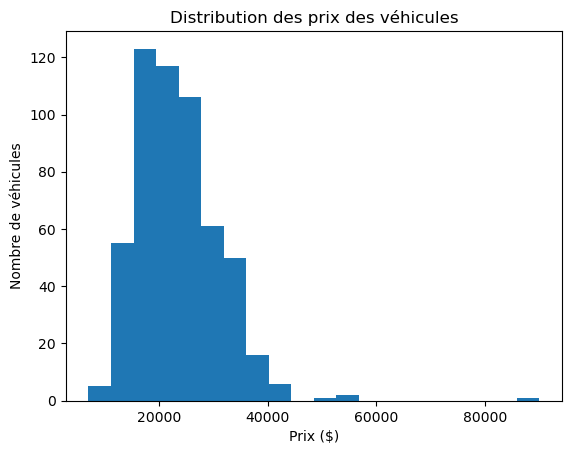

In [44]:
plt.hist(df_model["PRICE"], bins=20)

plt.xlabel("Prix ($)")
plt.ylabel("Nombre de véhicules")
plt.title("Distribution des prix des véhicules")

plt.show()

In [45]:
df_model.sort_values("PRICE", ascending=False).head(10)[
    ["YEAR", "MAKE", "MODEL", "KM", "PRICE"]
]

,YEAR,MAKE,MODEL,KM,PRICE
40,2020,Porsche,Taycan,35000,89999
189,2025,Chevrolet,Express Commercial Cutaway,35870,54995
142,2024,Ford,F-150 Lightning,88500,53995
202,2022,Chevrolet,Silverado 2500 HD,77080,50995
422,2022,Chevrolet,Silverado 1500,74547,43995
214,2025,Chevrolet,Silverado 1500,54474,43995
487,2025,Chevrolet,Silverado 1500,53518,43995
331,2024,Hyundai,Palisade,46117,43995
439,2022,Dodge,Charger,32886,41995
114,2025,Jeep,Grand Cherokee 4xe,46085,41995


### Vérification des prix élevés

Le prix maximal du jeu de données est de 89 999 $ et correspond à un Porsche Taycan 2020. Cette valeur est cohérente avec le type de véhicule et est donc conservée.

In [46]:
df_model[variables_categorielles].nunique().sort_values(ascending=False)

MODEL         135
MAKE           27
COLORF         19
BODYDESCF       7
DRIVETRAIN      5
FUEL            5
TRANSDESCF      2
dtype: int64

In [47]:
df_model.to_csv(
    "../data/interim/vehicles_clean.csv",
    index=False
)

print("Fichier sauvegardé dans data/interim/vehicles_clean.csv")

Fichier sauvegardé dans data/interim/vehicles_clean.csv


## Conclusion de la préparation des données

Le jeu de données initial contient 543 véhicules et 106 variables.
Pour ce projet, 11 variables explicatives ont été sélectionnées ainsi que la variable cible `PRICE`.

Les vérifications effectuées montrent :

- aucune valeur manquante dans les variables retenues ;
- aucun doublon ;
- aucune anomalie évidente nécessitant la suppression d'une observation ;
- des variables numériques et catégorielles qui devront être préparées différemment pour l'entraînement.

Le jeu de données préparé contient donc 543 observations et 12 colonnes. Il est sauvegardé dans `data/interim/vehicles_clean.csv`.